# FractalScope v2 — Direct Framebuffer Fractal Test

This notebook tests the new v2 render path:

```text
pixel_scheduler_top
  -> iter_core_array
  -> colour_palette
  -> pixel_write_engine_top
  -> PS HP1 DDR framebuffer
  -> VDMA MM2S
  -> HDMI
```

The old `reorder_buffer` and `packer` path is no longer used. Frame completion is detected using the pixel writer counters:

```text
PIXELS_WRITTEN == 1280 * 720
WRITE_ERRORS == 0
```

The display path uses a 32-bit framebuffer:

```text
pixel word      = 0x00RRGGBB
bytes_per_pixel = 4
stride          = 1280 * 4 = 5120 bytes
frame size      = 3,686,400 bytes
```


This version includes the Q4.22 fixed-point correction and Julia debug cells.


In [ ]:
hwh_file = "main_v1.hwh"

# Read the file using 'utf-8-sig' which automatically strips the hidden BOM
with open(hwh_file, "r", encoding="utf-8-sig") as f:
    clean_xml = f.read()

# Write it back as a pure, clean Linux text file
with open(hwh_file, "w", encoding="utf-8") as f:
    f.write(clean_xml)

print("✅ HWH file successfully sanitized! The hidden BOM has been destroyed.")

In [ ]:
!pip install pyserial*.whl

In [1]:
from pynq import Overlay, allocate, MMIO
import numpy as np
import time

# Update this to match the folder/name you copy to the PYNQ board.
# The .bit and .hwh must have the same base name and be in the same folder.
BIT_PATH = "/home/xilinx/jupyter_notebooks/Untitled Folder/main_v1.bit"

WIDTH = 1280
HEIGHT = 720
BPP = 4
STRIDE = WIDTH * BPP
FRAME_PIXELS = WIDTH * HEIGHT

# Current hardware fixed-point format used by the fractal pipeline.
# W = 26, signed, Q4.22. RTL iter_core uses FRAC = 22.
FIXED_FRAC_BITS = 22
FIXED_SCALE = 1 << FIXED_FRAC_BITS
FIXED_W = 26

# Fractal mode values from iter_core.
MODE_MANDEL  = 0
MODE_JULIA   = 1
MODE_BURNING = 2
MODE_TRICORN = 3

MODE_NAMES = {
    MODE_MANDEL: "mandelbrot",
    MODE_JULIA: "julia",
    MODE_BURNING: "burning_ship",
    MODE_TRICORN: "tricorn",
}

print("Configured for:")
print(f"  bitstream:  {BIT_PATH}")
print(f"  resolution: {WIDTH}x{HEIGHT}")
print(f"  bpp:        {BPP}")
print(f"  stride:     {STRIDE}")
print(f"  pixels:     {FRAME_PIXELS}")
print(f"  frame size: {FRAME_PIXELS * BPP} bytes")
print(f"  fixed:      Q4.{FIXED_FRAC_BITS} in {FIXED_W} bits")


Configured for:
  bitstream:  /home/xilinx/jupyter_notebooks/Untitled Folder/main_v1.bit
  resolution: 1280x720
  bpp:        4
  stride:     5120
  pixels:     921600
  frame size: 3686400 bytes
  fixed:      Q4.22 in 26 bits


## 1. Load overlay and find IP blocks

In [2]:
ol = Overlay(BIT_PATH)
ol.download()

print("Loaded overlay:", BIT_PATH)
print("\nDetected IP blocks:")
for name, info in ol.ip_dict.items():
    base = info.get("phys_addr", 0)
    rng = info.get("addr_range", 0)
    print(f"  {name:45s} @ 0x{base:08X}, range=0x{rng:X}")


Loaded overlay: /home/xilinx/jupyter_notebooks/Untitled Folder/main_v1.bit

Detected IP blocks:
  pixel_scheduler_top_0                         @ 0x40000000, range=0x1000
  pixel_write_engine_t_0                        @ 0x40001000, range=0x1000
  axi_gpio_0                                    @ 0x41200000, range=0x10000
  axi_gpio_1                                    @ 0x41210000, range=0x10000
  axi_gpio_2                                    @ 0x41220000, range=0x10000
  axi_gpio_3                                    @ 0x41230000, range=0x10000
  axi_vdma_0                                    @ 0x43000000, range=0x10000
  processing_system7_0                          @ 0x00000000, range=0x0


In [3]:
def find_ip_by_name_contains(substr):
    matches = [name for name in ol.ip_dict if substr.lower() in name.lower()]
    if not matches:
        raise RuntimeError(f"No IP name contains {substr!r}. Available: {list(ol.ip_dict)}")
    return matches[0]

VDMA_IP = find_ip_by_name_contains("axi_vdma")
WRITER_IP = find_ip_by_name_contains("pixel_write_engine")
SCHED_IP = find_ip_by_name_contains("pixel_scheduler_top")

print("Using:")
print("  VDMA IP:      ", VDMA_IP,   hex(ol.ip_dict[VDMA_IP]["phys_addr"]))
print("  Writer IP:    ", WRITER_IP, hex(ol.ip_dict[WRITER_IP]["phys_addr"]))
print("  Scheduler IP: ", SCHED_IP,  hex(ol.ip_dict[SCHED_IP]["phys_addr"]))

vdma = MMIO(ol.ip_dict[VDMA_IP]["phys_addr"], ol.ip_dict[VDMA_IP]["addr_range"])
writer = MMIO(ol.ip_dict[WRITER_IP]["phys_addr"], ol.ip_dict[WRITER_IP]["addr_range"])
sched = MMIO(ol.ip_dict[SCHED_IP]["phys_addr"], ol.ip_dict[SCHED_IP]["addr_range"])

print("MMIO handles created.")


Using:
  VDMA IP:       axi_vdma_0 0x43000000
  Writer IP:     pixel_write_engine_t_0 0x40001000
  Scheduler IP:  pixel_scheduler_top_0 0x40000000
MMIO handles created.


## 2. Register maps and helpers

In [4]:
# pixel_write_engine_top AXI-Lite register offsets
WR_CONTROL          = 0x00
WR_STATUS           = 0x04
WR_FRAMEBUFFER_BASE = 0x08
WR_PIXELS_ACCEPTED  = 0x0C
WR_PIXELS_WRITTEN   = 0x10
WR_WRITE_ERRORS     = 0x14
WR_FRAME_PIXELS     = 0x18
WR_GEOMETRY         = 0x1C

# Writer CONTROL bits
WR_START      = 1 << 0
WR_ENABLE     = 1 << 1
WR_SOFT_RESET = 1 << 2

# pixel_scheduler_top AXI-Lite register offsets
SCH_X_JUMP   = 0x00
SCH_Y_JUMP   = 0x04
SCH_X_MIN    = 0x08
SCH_Y_MIN    = 0x0C
SCH_JUL_C_R  = 0x10
SCH_JUL_C_I  = 0x14
SCH_MODE_ITER= 0x18
SCH_CONTROL  = 0x1C

# Scheduler CONTROL bits
SCH_RUN = 1 << 0

def decode_writer_status(status):
    return {
        "busy":  bool(status & 0x1),
        "done":  bool(status & 0x2),
        "error": bool(status & 0x4),
        "idle":  bool(status & 0x8),
        "raw":   status,
    }

def to_fixed_q3_23(value):
    raw = int(round(float(value) * FIXED_SCALE))
    min_val = -(1 << (FIXED_W - 1))
    max_val = (1 << (FIXED_W - 1)) - 1
    if raw < min_val or raw > max_val:
        raise ValueError(f"{value} converts to {raw}, outside signed {FIXED_W}-bit range")
    return raw & ((1 << FIXED_W) - 1)

def from_fixed_q3_23(raw):
    raw = int(raw) & ((1 << FIXED_W) - 1)
    if raw & (1 << (FIXED_W - 1)):
        raw -= 1 << FIXED_W
    return raw / FIXED_SCALE

def pack_mode_iter(mode, max_iter):
    mode = int(mode) & 0x7
    max_iter = int(max_iter) & 0xFFFF
    return (mode << 16) | max_iter

def show_writer():
    status = writer.read(WR_STATUS)
    geom = writer.read(WR_GEOMETRY)
    x_res = geom & 0xFFFF
    y_res = (geom >> 16) & 0xFFFF

    print("Writer:")
    print("  CONTROL          =", f"0x{writer.read(WR_CONTROL):08X}")
    print("  STATUS           =", decode_writer_status(status))
    print("  FRAMEBUFFER_BASE =", f"0x{writer.read(WR_FRAMEBUFFER_BASE):08X}")
    print("  PIXELS_ACCEPTED  =", writer.read(WR_PIXELS_ACCEPTED))
    print("  PIXELS_WRITTEN   =", writer.read(WR_PIXELS_WRITTEN))
    print("  WRITE_ERRORS     =", writer.read(WR_WRITE_ERRORS))
    print("  FRAME_PIXELS     =", writer.read(WR_FRAME_PIXELS))
    print(f"  GEOMETRY         = 0x{geom:08X} -> X={x_res}, Y={y_res}")

def show_scheduler_regs():
    vals = {
        "x_jump": sched.read(SCH_X_JUMP),
        "y_jump": sched.read(SCH_Y_JUMP),
        "x_min": sched.read(SCH_X_MIN),
        "y_min": sched.read(SCH_Y_MIN),
        "jul_c_r": sched.read(SCH_JUL_C_R),
        "jul_c_i": sched.read(SCH_JUL_C_I),
        "mode_iter": sched.read(SCH_MODE_ITER),
        "control": sched.read(SCH_CONTROL),
    }
    mode = (vals["mode_iter"] >> 16) & 0x7
    max_iter = vals["mode_iter"] & 0xFFFF

    print("Scheduler:")
    print(f"  x_jump   = 0x{vals['x_jump']:08X} -> {from_fixed_q3_23(vals['x_jump']):.12f}")
    print(f"  y_jump   = 0x{vals['y_jump']:08X} -> {from_fixed_q3_23(vals['y_jump']):.12f}")
    print(f"  x_min    = 0x{vals['x_min']:08X} -> {from_fixed_q3_23(vals['x_min']):.12f}")
    print(f"  y_min    = 0x{vals['y_min']:08X} -> {from_fixed_q3_23(vals['y_min']):.12f}")
    print(f"  jul_c_r  = 0x{vals['jul_c_r']:08X} -> {from_fixed_q3_23(vals['jul_c_r']):.12f}")
    print(f"  jul_c_i  = 0x{vals['jul_c_i']:08X} -> {from_fixed_q3_23(vals['jul_c_i']):.12f}")
    print(f"  mode     = {mode} ({MODE_NAMES.get(mode, 'unknown')})")
    print(f"  max_iter = {max_iter}")
    print(f"  control  = 0x{vals['control']:08X}")


In [ ]:
def reset_writer():
    writer.write(WR_CONTROL, WR_SOFT_RESET)
    time.sleep(0.001)
    writer.write(WR_CONTROL, 0x0)
    time.sleep(0.001)

def start_writer(scale = 1):
    ctrl_val = WR_ENABLE | WR_START | (scale << 4)
    writer.write(WR_CONTROL, ctrl_val)
    time.sleep(0.001)
    writer.write(WR_CONTROL, WR_ENABLE | (scale << 4))

def stop_writer():
    writer.write(WR_CONTROL, 0x0)

def hold_scheduler_reset():
    # The scheduler wrapper uses this run bit to release render_rst_n_out.
    sched.write(SCH_CONTROL, 0x0)
    time.sleep(0.001)

def start_scheduler(scale = 1):
    ctrl_val = SCH_RUN | (scale << 4)
    sched.write(SCH_CONTROL, ctrl_val)

def program_scheduler_view(
    center_r=0.0,
    center_i=0.0,
    x_width=3.5,
    max_iter=64,
    mode=MODE_MANDEL,
    julia_c=(-0.8, 0.156),
):
    # Preserve aspect ratio and keep pixel spacing equal in X and Y.
    y_width = x_width * HEIGHT / WIDTH

    x_min = center_r - x_width / 2.0
    y_min = center_i - y_width / 2.0

    x_jump = x_width / WIDTH
    y_jump = y_width / HEIGHT

    sched.write(SCH_X_JUMP, to_fixed_q3_23(x_jump))
    sched.write(SCH_Y_JUMP, to_fixed_q3_23(y_jump))
    sched.write(SCH_X_MIN, to_fixed_q3_23(x_min))
    sched.write(SCH_Y_MIN, to_fixed_q3_23(y_min))
    sched.write(SCH_JUL_C_R, to_fixed_q3_23(julia_c[0]))
    sched.write(SCH_JUL_C_I, to_fixed_q3_23(julia_c[1]))
    sched.write(SCH_MODE_ITER, pack_mode_iter(mode, max_iter))

    print("Programmed view:")
    print(f"  mode       = {mode} ({MODE_NAMES.get(mode, 'unknown')})")
    print(f"  center     = ({center_r:.12f}, {center_i:.12f})")
    print(f"  x_width    = {x_width:.12f}")
    print(f"  y_width    = {y_width:.12f}")
    print(f"  x range    = [{x_min:.12f}, {x_min + x_width:.12f}]")
    print(f"  y range    = [{y_min:.12f}, {y_min + y_width:.12f}]")
    print(f"  x_jump     = {x_jump:.12f}")
    print(f"  y_jump     = {y_jump:.12f}")
    print(f"  max_iter   = {max_iter}")
    print(f"  julia_c    = ({julia_c[0]:.12f}, {julia_c[1]:.12f})")


## Fixed-point scaling check

The RTL uses `FRAC = 22`, so the PS-side conversion must use Q4.22-style scaling. If this is wrong, Julia sets can collapse into nearly uniform escape colours.


In [6]:
# Fixed-point sanity check. This should use FRAC = 22.
FIXED_FRAC_BITS = 22
FIXED_SCALE = 1 << FIXED_FRAC_BITS
FIXED_W = 26

print("Fixed-point conversion:")
print("  FIXED_FRAC_BITS =", FIXED_FRAC_BITS)
print("  FIXED_SCALE     =", FIXED_SCALE)
print("  -0.8 encoded    =", hex(to_fixed_q3_23(-0.8)))
print("  -0.8 decoded    =", from_fixed_q3_23(to_fixed_q3_23(-0.8)))
print("  0.156 encoded   =", hex(to_fixed_q3_23(0.156)))
print("  0.156 decoded   =", from_fixed_q3_23(to_fixed_q3_23(0.156)))

assert FIXED_FRAC_BITS == 22
assert abs(from_fixed_q3_23(to_fixed_q3_23(-0.8)) + 0.8) < 1e-5
assert abs(from_fixed_q3_23(to_fixed_q3_23(0.156)) - 0.156) < 1e-5

print("Fixed-point scaling check: PASS")


Fixed-point conversion:
  FIXED_FRAC_BITS = 22
  FIXED_SCALE     = 4194304
  -0.8 encoded    = 0x3cccccd
  -0.8 decoded    = -0.7999999523162842
  0.156 encoded   = 0x9fbe7
  0.156 decoded   = 0.15599989891052246
Fixed-point scaling check: PASS


## 3. Basic AXI-Lite sanity checks

In [7]:
show_writer()

geom = writer.read(WR_GEOMETRY)
frame_pixels = writer.read(WR_FRAME_PIXELS)
expected_geom = (HEIGHT << 16) | WIDTH

print("\nExpected:")
print(f"  FRAME_PIXELS = {FRAME_PIXELS}")
print(f"  GEOMETRY     = 0x{expected_geom:08X}")

assert frame_pixels == FRAME_PIXELS, f"FRAME_PIXELS mismatch: got {frame_pixels}, expected {FRAME_PIXELS}"
assert geom == expected_geom, f"GEOMETRY mismatch: got 0x{geom:08X}, expected 0x{expected_geom:08X}"

print("\nWriter AXI-Lite readback: PASS")


Writer:
  CONTROL          = 0x00000000
  STATUS           = {'busy': False, 'done': False, 'error': False, 'idle': True, 'raw': 8}
  FRAMEBUFFER_BASE = 0x00000000
  PIXELS_ACCEPTED  = 0
  PIXELS_WRITTEN   = 0
  WRITE_ERRORS     = 0
  FRAME_PIXELS     = 921600
  GEOMETRY         = 0x02D00500 -> X=1280, Y=720

Expected:
  FRAME_PIXELS = 921600
  GEOMETRY     = 0x02D00500

Writer AXI-Lite readback: PASS


In [8]:
hold_scheduler_reset()

program_scheduler_view(
    center_r=0.0,
    center_i=0.0,
    x_width=3.5,
    max_iter=64,
    mode=MODE_MANDEL,
    julia_c=(-0.8, 0.156),
)

show_scheduler_regs()
print("\nScheduler AXI-Lite write/read sanity: PASS if values above look sensible.")


Programmed view:
  mode       = 0 (mandelbrot)
  center     = (0.000000000000, 0.000000000000)
  x_width    = 3.500000000000
  y_width    = 1.968750000000
  x range    = [-1.750000000000, 1.750000000000]
  y range    = [-0.984375000000, 0.984375000000]
  x_jump     = 0.002734375000
  y_jump     = 0.002734375000
  max_iter   = 64
  julia_c    = (-0.800000000000, 0.156000000000)
Scheduler:
  x_jump   = 0x00002CCD -> 0.002734422684
  y_jump   = 0x00002CCD -> 0.002734422684
  x_min    = 0x03900000 -> -1.750000000000
  y_min    = 0x03C10000 -> -0.984375000000
  jul_c_r  = 0x03CCCCCD -> -0.799999952316
  jul_c_i  = 0x0009FBE7 -> 0.155999898911
  mode     = 0 (mandelbrot)
  max_iter = 64
  control  = 0x00000000

Scheduler AXI-Lite write/read sanity: PASS if values above look sensible.


## 4. Allocate framebuffer

### **Update**: Using two framebuffers

In [9]:
fb1 = allocate(shape=(HEIGHT, WIDTH), dtype=np.uint32)
fb2 = allocate(shape=(HEIGHT, WIDTH), dtype=np.uint32)
 
print("Framebuffer 1:")
print("  physical address:", hex(fb1.physical_address))
print("  nbytes:          ", fb1.nbytes)
print("  expected nbytes: ", FRAME_PIXELS * BPP)

print("Framebuffer 2:")
print("  physical address:", hex(fb2.physical_address))
print("  nbytes:          ", fb2.nbytes)
print("  expected nbytes: ", FRAME_PIXELS * BPP)

assert fb1.nbytes == FRAME_PIXELS * BPP
assert fb2.nbytes == FRAME_PIXELS * BPP

fb1[:] = 0x00000000
fb2[:] = 0x00000000
fb1.flush()
fb2.flush()

print("Framebuffers cleared and flushed.")


Framebuffer 1:
  physical address: 0x15900000
  nbytes:           3686400
  expected nbytes:  3686400
Framebuffer 2:
  physical address: 0x15d00000
  nbytes:           3686400
  expected nbytes:  3686400
Framebuffers cleared and flushed.


## 5. VDMA MM2S display helpers

This is the same display-side setup used in the successful writer smoke test, but now the framebuffer will be filled by the fractal pipeline.


In [10]:
# AXI VDMA MM2S register offsets
MM2S_DMACR         = 0x00
MM2S_DMASR         = 0x04
PARK_PTR_REG       = 0x28
MM2S_VSIZE         = 0x50
MM2S_HSIZE         = 0x54
MM2S_FRMDLY_STRIDE = 0x58
MM2S_START_ADDR1   = 0x5C
MM2S_START_ADDR2   = 0x60
MM2S_START_ADDR3   = 0x64

VDMA_DMACR_RUNSTOP = 1 << 0
VDMA_DMACR_CIRC    = 1 << 1
VDMA_DMACR_RESET   = 1 << 2

def decode_vdma_status(s):
    flags = []
    if s & (1 << 0):  flags.append("HALTED")
    if s & (1 << 1):  flags.append("VDMA_INTERNAL_ERR")
    if s & (1 << 4):  flags.append("SLAVE_ERR")
    if s & (1 << 5):  flags.append("DECODE_ERR")
    if s & (1 << 8):  flags.append("SOF_EARLY_ERR")
    if s & (1 << 12): flags.append("FRAME_COUNT_IRQ")
    if s & (1 << 13): flags.append("DELAY_COUNT_IRQ")
    if s & (1 << 14): flags.append("ERROR_IRQ")
    if s & (1 << 16): flags.append("PARKED_OR_FRAME_SYNC")
    return flags

def show_mm2s():
    cr = vdma.read(MM2S_DMACR)
    sr = vdma.read(MM2S_DMASR)
    print(f"MM2S_DMACR       = 0x{cr:08X}")
    print(f"MM2S_DMASR       = 0x{sr:08X} {decode_vdma_status(sr)}")
    print(f"MM2S_START_ADDR1 = 0x{vdma.read(MM2S_START_ADDR1):08X}")
    print(f"MM2S_HSIZE       = {vdma.read(MM2S_HSIZE)}")
    print(f"MM2S_STRIDE      = {vdma.read(MM2S_FRMDLY_STRIDE) & 0xFFFF}")
    print(f"MM2S_VSIZE       = {vdma.read(MM2S_VSIZE)}")

def reset_mm2s(timeout_s=1.0):
    vdma.write(MM2S_DMACR, VDMA_DMACR_RESET)

    t0 = time.time()
    while time.time() - t0 < timeout_s:
        if (vdma.read(MM2S_DMACR) & VDMA_DMACR_RESET) == 0:
            return True
        time.sleep(0.001)

    return False

def start_mm2s(framebuffer1_phys, framebuffer2_phys, width=WIDTH, height=HEIGHT, bpp=BPP):
    stride = width * bpp
    hsize = width * bpp

    print("Resetting MM2S...")
    ok = reset_mm2s()
    print("MM2S reset ok:", ok)
    show_mm2s()

    # Clear sticky status bits where supported.
    vdma.write(MM2S_DMASR, 0x0000FFFF)

    # Update - AADR 1 to fb1, ADDR 2 to fb2
    vdma.write(MM2S_START_ADDR1, framebuffer1_phys)
    vdma.write(MM2S_START_ADDR2, framebuffer2_phys)

    # Update - Parked mode instead of cicular mode
    vdma.write(MM2S_DMACR, VDMA_DMACR_RUNSTOP)

    # Update - Park pointer  for reading buffer
    vdma.write(PARK_PTR_REG, 0)

    # Program geometry. VSIZE is usually written last to start the transfer.
    vdma.write(MM2S_FRMDLY_STRIDE, stride)
    vdma.write(MM2S_HSIZE, hsize)
    vdma.write(MM2S_VSIZE, height)

    time.sleep(0.1)
    print("\nAfter MM2S start:")
    show_mm2s()


## 6. Render helpers

The key v2 render sequence is:

```text
1. Hold scheduler reset
2. Reset writer
3. Clear framebuffer
4. Program framebuffer_base into writer
5. Start VDMA MM2S display
6. Start writer
7. Program scheduler parameters
8. Release scheduler run bit
9. Poll writer until PIXELS_WRITTEN == 921600
```


In [ ]:
# Global declaration for front buffer
current_front_is_1 = True


def poll_writer(timeout_s=20.0, print_every=0.2):
    t0 = time.time()
    next_print = t0
    last_written = -1
    stagnant_count = 0

    while True:
        now = time.time()
        status = writer.read(WR_STATUS)
        accepted = writer.read(WR_PIXELS_ACCEPTED)
        written = writer.read(WR_PIXELS_WRITTEN)
        errors = writer.read(WR_WRITE_ERRORS)

        if now >= next_print:
            print(
                f"t={now-t0:7.3f}s "
                f"status=0x{status:08X} "
                f"accepted={accepted:7d} "
                f"written={written:7d} "
                f"errors={errors}"
            )
            next_print = now + print_every

        if written == last_written:
            stagnant_count += 1
        else:
            stagnant_count = 0
            last_written = written

        if written >= FRAME_PIXELS:
            print("Writer reached full frame.")
            break

        if errors != 0:
            print("Writer reported AXI write errors.")
            break

        if now - t0 > timeout_s:
            print("Timeout.")
            break

        time.sleep(0.005)

    elapsed = time.time() - t0
    print()
    show_writer()
    print(f"Elapsed: {elapsed:.3f}s")
    if writer.read(WR_PIXELS_WRITTEN) > 0:
        print(f"Pixel write rate: {writer.read(WR_PIXELS_WRITTEN) / elapsed / 1e6:.3f} Mpixels/s")
    return {
        "elapsed": elapsed,
        "accepted": writer.read(WR_PIXELS_ACCEPTED),
        "written": writer.read(WR_PIXELS_WRITTEN),
        "errors": writer.read(WR_WRITE_ERRORS),
        "status": writer.read(WR_STATUS),
    }

def render_fractal(
    *,
    mode=MODE_MANDEL,
    center_r=0.0,
    center_i=0.0,
    x_width=3.5,
    max_iter=64,
    julia_c=(-0.8, 0.156),
    clear_colour=0x00000000,
    display=True,
    timeout_s=20.0,
):
    start_render = time.time()
    global current_front_is_1
    times = []
    print("=" * 72)
    print(f"Rendering {MODE_NAMES.get(mode, mode)} (Progressive)")
    print("=" * 72)

    for current_scale in [8, 4, 2, 1]:
        print(f"--- Pass: Scale {current_scale}x ---")
        
        # 1. Determine front buffer
        if current_front_is_1:
            fb_front_phys = fb1.physical_address
            fb_back_phys  = fb2.physical_address
            vdma_frame_idx = 0
        else:
            fb_front_phys = fb2.physical_address
            fb_back_phys  = fb1.physical_address
            vdma_frame_idx = 1

        # 2. VDMA reads from the front buffer (showing previous pass)
        vdma.write(PARK_PTR_REG, vdma_frame_idx)

        # 3. PL writes to back buffer
        writer.write(WR_FRAMEBUFFER_BASE, fb_back_phys)

        hold_scheduler_reset()
        reset_writer()

        # 4. Fire the hardware with the current scale!
        start_writer(scale=current_scale)
        program_scheduler_view(center_r=center_r, center_i=center_i, x_width=x_width, max_iter=max_iter, mode=mode, julia_c=julia_c)
        start_scheduler(scale=current_scale)

        # 5. Wait for the hardware to finish this pass
        result = poll_writer(timeout_s=timeout_s)
        hold_scheduler_reset()

        # 6. Swap the toggle so the NEXT pass draws to the other buffer
        current_front_is_1 = not current_front_is_1
        
        tmp_render = time.time()
        times.append(tmp_render-start_render)

    if current_front_is_1:
        vdma.write(PARK_PTR_REG, 0)
    else:
        vdma.write(PARK_PTR_REG, 1)
        
    end_render = time.time()
    print(f"\nTotal Progressive Render Time: {end_render - start_render:.3f}s")
    
    return result, times


## 7. HDMI display - Initializer

In [12]:
start_mm2s(fb1.physical_address, fb2.physical_address, WIDTH, HEIGHT, BPP)

Resetting MM2S...
MM2S reset ok: True
MM2S_DMACR       = 0x00010002
MM2S_DMASR       = 0x00010001 ['HALTED', 'PARKED_OR_FRAME_SYNC']
MM2S_START_ADDR1 = 0x00000000
MM2S_HSIZE       = 0
MM2S_STRIDE      = 0
MM2S_VSIZE       = 0

After MM2S start:
MM2S_DMACR       = 0x00010001
MM2S_DMASR       = 0x00011000 ['FRAME_COUNT_IRQ', 'PARKED_OR_FRAME_SYNC']
MM2S_START_ADDR1 = 0x15900000
MM2S_HSIZE       = 5120
MM2S_STRIDE      = 5120
MM2S_VSIZE       = 720


## 8. Controller Implemention

Requires controller, but if available run tests through here

In [43]:
import serial
import time

# 1. Connect to the Pico
try:
    pico = serial.Serial('/dev/ttyACM0', baudrate=115200, timeout=0.1)
    print("Successfully connected to Pico controller.")
except Exception as e:
    print(f"Failed to connect to controller: {e}")

# Quick CRC8-CCITT implementation
def calc_crc8(payload_bytes):
    crc = 0x00
    for b in payload_bytes:
        crc ^= b
        for _ in range(8):
            if crc & 0x80:
                crc = ((crc << 1) ^ 0x07) & 0xFF
            else:
                crc = (crc << 1) & 0xFF
    return crc

# 2. Establish the starting frame
current_mode     = 1  # 1 is Julia mode based on your logs
current_center_r = -0.75
current_center_i = 0.0
current_x_width  = 3.0
current_max_iter = 64
current_julia_c  = (-0.8, 0.156)

# Sensitivities 
PAN_SPEED  = 0.00001  
ZOOM_SPEED = 0.01   
ITER_SPEED = 2      

print("Listening for controller inputs... Press the Stop button (■) in Jupyter to exit.")

try:
    pico.reset_input_buffer()
    
    while True:
        # Read the raw packet
        line = pico.readline().decode('ascii', errors='ignore').strip()
        
        # 3. Look for our fixed "TDT" prefix
        if line.startswith("TDT,"):
            
            last_comma = line.rfind(',')
            payload_str = line[:last_comma]
            received_crc_hex = line[last_comma+1:]
            
            # Validate CRC
            if f"{calc_crc8(payload_str.encode('ascii')):02X}" != received_crc_hex.upper():
                continue 
                
            parts  = payload_str.split(',')
            btn    = int(parts[2], 16)
            zoom_d = int(parts[3])
            iter_d = int(parts[4])
            jx     = int(parts[5])
            jy     = int(parts[6])
            
            # --- Process Button Logic ---
            if (btn & 0x01): 
                current_mode = 0 # Mandelbrot
            elif (btn & 0x02):
                current_mode = 1 # Julia
                
            # --- Process Math & Geometry ---
            
            # Update Iterations
            if iter_d != 0:
                current_max_iter += (iter_d * ITER_SPEED)
                if current_max_iter < 8: current_max_iter = 8 
                if current_max_iter > 1000: current_max_iter = 1000
            
            # Update Zoom
            if zoom_d != 0:
                zoom_factor = 1.0 - (zoom_d * ZOOM_SPEED)
                current_x_width *= zoom_factor
                
            # Update Pan 
            if jx != 0 or jy != 0:
                current_center_r += (jy * PAN_SPEED * current_x_width)
                current_center_i += (jx * PAN_SPEED * current_x_width)
                LIMIT = 4.0 
                if current_center_r > LIMIT: current_center_r = LIMIT
                if current_center_r < -LIMIT: current_center_r = -LIMIT
                if current_center_i > LIMIT: current_center_i = LIMIT
                if current_center_i < -LIMIT: current_center_i = -LIMIT
                
            # --- Push to Hardware ---
            if jx != 0 or jy != 0 or zoom_d != 0 or iter_d != 0 or btn != 0:
                render_fractal(
                    mode=current_mode,
                    center_r=current_center_r,
                    center_i=current_center_i,
                    x_width=current_x_width,
                    max_iter=int(current_max_iter),
                    julia_c=current_julia_c,
                    display=True 
                )

except KeyboardInterrupt:
    pico.close()
    print("Controller loop gracefully closed.")
except Exception as e:
    pico.close()
    print(f"Error encountered: {e}")

Successfully connected to Pico controller.
Listening for controller inputs... Press the Stop button (■) in Jupyter to exit.
Rendering julia
Programmed view:
  mode       = 1 (julia)
  center     = (-0.750000000000, 0.003540000000)
  x_width    = 3.000000000000
  y_width    = 1.687500000000
  x range    = [-2.250000000000, 0.750000000000]
  y range    = [-0.840210000000, 0.847290000000]
  x_jump     = 0.002343750000
  y_jump     = 0.002343750000
  max_iter   = 64
  julia_c    = (-0.800000000000, 0.156000000000)
t=  0.000s status=0x00000001 accepted=    191 written=    239 errors=0
t=  0.204s status=0x00000001 accepted= 554503 written= 554550 errors=0
Writer reached full frame.

Writer:
  CONTROL          = 0x00000002
  STATUS           = {'busy': False, 'done': True, 'error': False, 'idle': True, 'raw': 10}
  FRAMEBUFFER_BASE = 0x15D00000
  PIXELS_ACCEPTED  = 921600
  PIXELS_WRITTEN   = 921600
  WRITE_ERRORS     = 0
  FRAME_PIXELS     = 921600
  GEOMETRY         = 0x02D00500 -> X=1280, 

## 9. First hardware render: Mandelbrot, low iteration count

Start with `max_iter=32` or `64`. Once this works, increase it.

**Only use this if the controller is not available**


In [ ]:
result, render_time = render_fractal(
    mode=MODE_MANDEL,
    center_r=0.0,
    center_i=0.0,
    x_width=3.5,
    max_iter=64,
    display=True,
    timeout_s=20.0,
)

assert result["errors"] == 0, "Writer reported AXI write errors"
assert result["written"] == FRAME_PIXELS, f"Only wrote {result['written']} / {FRAME_PIXELS} pixels"

print("Mandelbrot v2 render: PASS")
print(f"The render time for Mandelbrot v2 is {render_time} seconds")


## 10. Inspect framebuffer from Python

This is useful if HDMI is blank or colours look suspicious. It reads the PL-written framebuffer back to the PS.


In [44]:
# This functionn chooses the correct frame buffer

def get_latest_buffer():

    if current_front_is_1:
        return fb1
    else:
        return fb2

def framebuffer_stats():
    fb = get_latest_buffer()
    fb.invalidate()
    arr = np.asarray(fb)

    print("Framebuffer sample pixels:")
    for x, y in [(0, 0), (WIDTH // 2, HEIGHT // 2), (WIDTH - 1, HEIGHT - 1), (10, 20)]:
        print(f"  fb[{y:3d},{x:4d}] = 0x{int(arr[y, x]):08X}")

    print("\nBasic stats:")
    print("  min:", hex(int(arr.min())))
    print("  max:", hex(int(arr.max())))
    print("  unique sample count in first 200x200:", len(np.unique(arr[:200, :200])))

framebuffer_stats()


Framebuffer sample pixels:
  fb[  0,   0] = 0x00FFFF00
  fb[360, 640] = 0x00FFFF00
  fb[719,1279] = 0x00FFFF00
  fb[ 20,  10] = 0x00FFFF00

Basic stats:
  min: 0xff00
  max: 0xffff00
  unique sample count in first 200x200: 2


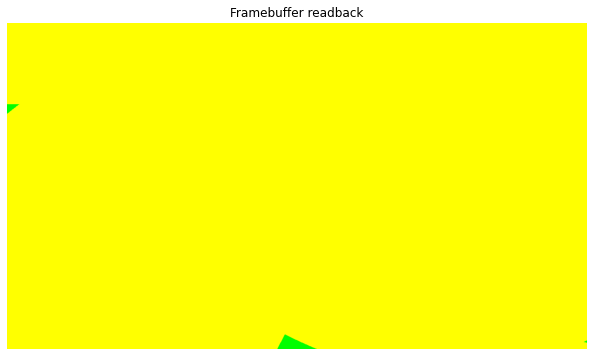

In [45]:
# Optional visualisation in the notebook.
# This is slower than HDMI, but useful for debugging.
try:
    import matplotlib.pyplot as plt
    fb = get_latest_buffer()
    fb.invalidate()
    raw = np.asarray(fb)

    rgb = np.empty((HEIGHT, WIDTH, 3), dtype=np.uint8)
    rgb[..., 0] = (raw >> 16) & 0xFF
    rgb[..., 1] = (raw >> 8) & 0xFF
    rgb[..., 2] = raw & 0xFF

    plt.figure(figsize=(12, 6))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title("Framebuffer readback")
    plt.show()
except Exception as e:
    print("Matplotlib display skipped:", e)


## 11. Additional fractal tests

In [ ]:
# Zoomed Mandelbrot
result, render_time = render_fractal(
    mode=MODE_MANDEL,
    center_r=-0.75,
    center_i=0.0,
    x_width=2.0,
    max_iter=96,
    display=True,
    timeout_s=30.0,
)

print(result)


In [ ]:
# Julia set
result, render_time = render_fractal(
    mode=MODE_JULIA,
    center_r=0.0,
    center_i=0.0,
    x_width=3.2,
    max_iter=96,
    julia_c=(-0.8, 0.156),
    display=True,
    timeout_s=30.0,
)

print(result)


In [ ]:
# Burning Ship
result, render_time = render_fractal(
    mode=MODE_BURNING,
    center_r=-0.5,
    center_i=-0.5,
    x_width=3.5,
    max_iter=96,
    display=True,
    timeout_s=30.0,
)

print(result)


In [ ]:
# Tricorn
result, render_time = render_fractal(
    mode=MODE_TRICORN,
    center_r=0.0,
    center_i=0.0,
    x_width=3.5,
    max_iter=96,
    display=True,
    timeout_s=30.0,
)

print(result)


## 12. Manual render function for exploration

Use this cell to experiment interactively.


In [ ]:
# Example: edit these values and rerun.
custom, render_time = render_fractal(
    mode=MODE_MANDEL,
    center_r=-0.7435,
    center_i=0.1314,
    x_width=0.05,
    max_iter=128,
    display=True,
    timeout_s=40.0,
)

print(custom)


## Julia debug suite

Use these cells if Julia initially appears as a solid colour. They verify:

```text
1. Julia mode is actually written into the scheduler register.
2. Julia constants are encoded using Q4.22 scaling.
3. Different Julia constants produce different framebuffer contents.
4. The framebuffer has colour diversity, even if HDMI colour ordering looks wrong.
```


In [ ]:
# Julia scheduler register sanity check.
hold_scheduler_reset()

program_scheduler_view(
    center_r=0.0,
    center_i=0.0,
    x_width=3.2,
    max_iter=128,
    mode=MODE_JULIA,
    julia_c=(-0.4, 0.6),
)

show_scheduler_regs()

mode_iter = sched.read(SCH_MODE_ITER)
mode = (mode_iter >> 16) & 0x7
max_iter = mode_iter & 0xFFFF

print()
print("Raw mode_iter:", hex(mode_iter))
print("Decoded mode:", mode)
print("Decoded max_iter:", max_iter)
print("Raw jul_c_r:", hex(sched.read(SCH_JUL_C_R)))
print("Raw jul_c_i:", hex(sched.read(SCH_JUL_C_I)))
print("Decoded jul_c_r:", from_fixed_q3_23(sched.read(SCH_JUL_C_R)))
print("Decoded jul_c_i:", from_fixed_q3_23(sched.read(SCH_JUL_C_I)))

assert mode == MODE_JULIA, f"Expected Julia mode {MODE_JULIA}, got {mode}"
assert max_iter == 128, f"Expected max_iter 128, got {max_iter}"
assert abs(from_fixed_q3_23(sched.read(SCH_JUL_C_R)) - (-0.4)) < 1e-5
assert abs(from_fixed_q3_23(sched.read(SCH_JUL_C_I)) - 0.6) < 1e-5

print("Julia scheduler register check: PASS")


In [ ]:
def framebuffer_colour_report(sample_h=HEIGHT, sample_w=WIDTH, top_n=12):
    fb = get_latest_buffer()
    fb.invalidate()
    raw = np.asarray(fb)

    sample = raw[:sample_h, :sample_w].reshape(-1)
    unique, counts = np.unique(sample, return_counts=True)

    order = np.argsort(counts)[::-1]

    print("Framebuffer colour report:")
    print("  sampled pixels:", sample.size)
    print("  unique colours:", len(unique))
    print("  top colours:")

    for i in range(min(top_n, len(unique))):
        colour = int(unique[order[i]])
        count = int(counts[order[i]])
        pct = 100.0 * count / sample.size

        r = (colour >> 16) & 0xFF
        g = (colour >> 8) & 0xFF
        b = colour & 0xFF

        print(
            f"  {i:2d}: 0x{colour:08X} "
            f"R={r:3d} G={g:3d} B={b:3d} "
            f"count={count:7d} ({pct:6.2f}%)"
        )

def show_framebuffer_rgb_and_bgr():
    # Shows both interpretations. If intended cyan appears yellow on HDMI,
    # red and blue are likely swapped by the display path.
    try:
        import matplotlib.pyplot as plt
        fb = get_latest_buffer()

        fb.invalidate()
        raw = np.asarray(fb)

        rgb = np.empty((HEIGHT, WIDTH, 3), dtype=np.uint8)
        rgb[..., 0] = (raw >> 16) & 0xFF
        rgb[..., 1] = (raw >> 8) & 0xFF
        rgb[..., 2] = raw & 0xFF

        bgr_swapped = rgb[..., ::-1]

        plt.figure(figsize=(12, 6))
        plt.imshow(rgb)
        plt.axis("off")
        plt.title("Framebuffer interpreted as 0x00RRGGBB")
        plt.show()

        plt.figure(figsize=(12, 6))
        plt.imshow(bgr_swapped)
        plt.axis("off")
        plt.title("Framebuffer with R/B swapped preview")
        plt.show()
    except Exception as e:
        print("Matplotlib preview skipped:", e)

print("Framebuffer colour-report helpers ready.")


In [ ]:
JULIA_DEBUG_PRESETS = [
    {
        "name": "classic dendrite",
        "c": (-0.8, 0.156),
        "center": (0.0, 0.0),
        "x_width": 3.2,
        "max_iter": 128,
    },
    {
        "name": "spiral",
        "c": (-0.4, 0.6),
        "center": (0.0, 0.0),
        "x_width": 3.2,
        "max_iter": 128,
    },
    {
        "name": "rabbit-ish",
        "c": (-0.123, 0.745),
        "center": (0.0, 0.0),
        "x_width": 3.2,
        "max_iter": 128,
    },
    {
        "name": "fine filaments",
        "c": (0.285, 0.01),
        "center": (0.0, 0.0),
        "x_width": 3.2,
        "max_iter": 128,
    },
    {
        "name": "dust/detail",
        "c": (-0.70176, -0.3842),
        "center": (0.0, 0.0),
        "x_width": 3.2,
        "max_iter": 160,
    },
    {
        "name": "high-detail spiral",
        "c": (-0.835, -0.2321),
        "center": (0.0, 0.0),
        "x_width": 3.2,
        "max_iter": 160,
    },
]

for i, p in enumerate(JULIA_DEBUG_PRESETS):
    print(
        f"{i}: {p['name']:20s} "
        f"c=({p['c'][0]}, {p['c'][1]}), "
        f"x_width={p['x_width']}, max_iter={p['max_iter']}"
    )


In [ ]:
# Render one Julia preset by index.
preset_index = 1

p = JULIA_DEBUG_PRESETS[preset_index]

result, render_time = render_fractal(
    mode=MODE_JULIA,
    center_r=p["center"][0],
    center_i=p["center"][1],
    x_width=p["x_width"],
    max_iter=p["max_iter"],
    julia_c=p["c"],
    display=True,
    timeout_s=50.0,
)

print()
print("Rendered Julia preset:")
print("  index:", preset_index)
print("  name:", p["name"])
print("  c:", p["c"])
print("  result:", result)

framebuffer_stats()
framebuffer_colour_report(top_n=12)


In [ ]:
# Render all Julia presets one by one.
# This is interactive: press Enter between renders so you can inspect HDMI.

for i, p in enumerate(JULIA_DEBUG_PRESETS):
    print("\n" + "=" * 72)
    print(f"Julia preset {i}: {p['name']}")
    print(f"c = {p['c']}")
    print("=" * 72)

    result, render_time = render_fractal(
        mode=MODE_JULIA,
        center_r=p["center"][0],
        center_i=p["center"][1],
        x_width=p["x_width"],
        max_iter=p["max_iter"],
        julia_c=p["c"],
        display=True,
        timeout_s=50.0,
    )

    print("result:", result)
    framebuffer_colour_report(top_n=8)

    if i != len(JULIA_DEBUG_PRESETS) - 1:
        input("Press Enter to render the next Julia preset...")


In [ ]:
# Julia zoom/pan test.
# The image should visibly change across these views if Julia z0 uses pixel coordinates correctly.

c = (-0.4, 0.6)

julia_views = [
    {"name": "full view",       "center": (0.0, 0.0),       "x_width": 3.2,  "max_iter": 128},
    {"name": "moderate zoom",   "center": (0.0, 0.0),       "x_width": 1.6,  "max_iter": 160},
    {"name": "offset zoom",     "center": (-0.25, 0.15),    "x_width": 0.8,  "max_iter": 192},
    {"name": "close detail",    "center": (-0.35, 0.22),    "x_width": 0.35, "max_iter": 224},
]

for i, view in enumerate(julia_views):
    print("\n" + "=" * 72)
    print(f"Julia zoom test {i}: {view['name']}")
    print("=" * 72)

    result, render_time = render_fractal(
        mode=MODE_JULIA,
        center_r=view["center"][0],
        center_i=view["center"][1],
        x_width=view["x_width"],
        max_iter=view["max_iter"],
        julia_c=c,
        display=True,
        timeout_s=60.0,
    )

    print("result:", result)
    framebuffer_colour_report(top_n=8)

    if i != len(julia_views) - 1:
        input("Press Enter for next zoom level...")


## RGB/BGR note

If intended cyan appears yellow on HDMI, the display path is almost certainly swapping red and blue. That does not mean the fractal compute path is broken.

The likely hardware fix is in the pixel writer packing:

```systemverilog
// Current:
pixel_word = {8'h00, in_r, in_g, in_b};

// If HDMI effectively expects BGR:
pixel_word = {8'h00, in_b, in_g, in_r};
```

Make this as a separate tiny RTL checkpoint after the Julia geometry/output is confirmed.


In [ ]:
# Optional: compare normal RGB interpretation and R/B-swapped preview in the notebook.
show_framebuffer_rgb_and_bgr()


## Troubleshooting

### Writer counters stay at zero
Likely causes:
- scheduler was not released with `SCH_CONTROL = 1`
- scheduler AXI register map mismatch
- render pipeline reset still asserted
- `iter_core_array -> colour_palette -> writer` valid/ready path is broken

Check:

```python
show_scheduler_regs()
show_writer()
```

### `PIXELS_ACCEPTED` increases but `PIXELS_WRITTEN` does not
Likely causes:
- writer `m00_axi` to HP1 DDR issue
- HP1 clock/reset/address issue
- SmartConnect writer DDR path issue

This worked in the test-pattern smoke test, so if it fails now, compare the writer DDR path against the smoke-test design.

### `PIXELS_WRITTEN == 921600`, but HDMI is black
The fractal writer path probably worked. Check:
- VDMA MM2S status
- `MM2S_HSIZE = 5120`
- `MM2S_STRIDE = 5120`
- `MM2S_VSIZE = 720`
- framebuffer readback using the matplotlib/debug cells

### Screen updates progressively or tears
Expected for v2.0 single-buffer rendering. Double buffering is the next architecture step after this works.

### Colours look strange
This first v2 test still uses the existing `colour_palette`. The writer stores `0x00RRGGBB`; if HDMI byte order is wrong, the display path may need a byte-order adjustment later.
